In [2]:
import numpy as np
import pandas as pd
# give you file path here
dataset = pd.read_csv(r"C:\Users\KIIT\Downloads\Telco-Customer-Churn.csv")
dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(dataset.isnull().sum())
print(dataset.describe())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


Churn
No     5174
Yes    1869
Name: count, dtype: int64


C:\Users\KIIT\AppData\Local\Temp\ipykernel_6024\676724233.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=dataset, palette='coolwarm')


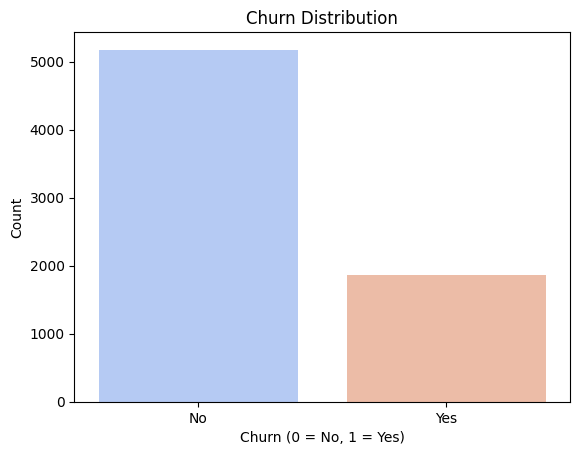

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
print(dataset['Churn'].value_counts())
sns.countplot(x='Churn', data=dataset, palette='coolwarm')
plt.title('Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

In [7]:
dataset['TotalCharges'] = pd.to_numeric(dataset['TotalCharges'], errors='coerce')
dataset['TotalCharges'] = dataset['TotalCharges'].fillna(dataset['TotalCharges'].median())

In [6]:
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 
                    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 
                    'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
for col in categorical_cols:
    dataset[col] = labelencoder.fit_transform(dataset[col])

In [8]:
from sklearn.model_selection import train_test_split
X = dataset.drop(['customerID', 'Churn'], axis=1)
y = dataset['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [11]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.78


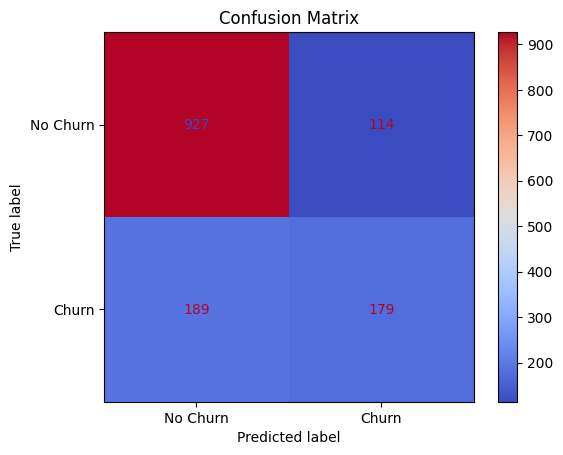

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(cmap="coolwarm")
plt.title('Confusion Matrix')
plt.show()

Train shape: (5282, 19)
Test shape : (1761, 19)

Class distribution in train:
 Churn
0    0.735
1    0.265
Name: proportion, dtype: float64

=== Performance on Test Set ===
Accuracy : 0.7831
Precision: 0.5791
Recall   : 0.6660
F1       : 0.6195
ROC-AUC  : 0.8378

Classification Report:
              precision    recall  f1-score   support

           0     0.8725    0.8253    0.8483      1294
           1     0.5791    0.6660    0.6195       467

    accuracy                         0.7831      1761
   macro avg     0.7258    0.7457    0.7339      1761
weighted avg     0.7947    0.7831    0.7876      1761



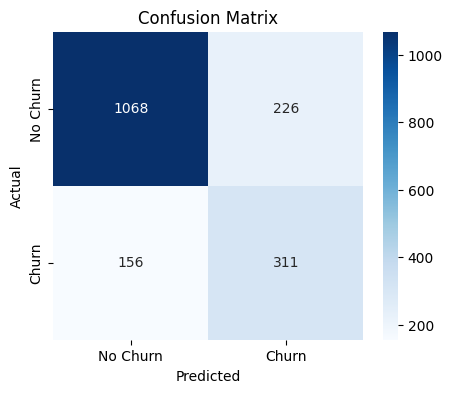

In [14]:
# ────────────────────────────────────────────────
# 1. Imports
# ────────────────────────────────────────────────
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: silence warnings if you want
# import warnings
# warnings.filterwarnings('ignore')

# ────────────────────────────────────────────────
# 2. Assuming your data is already loaded & preprocessed
#    (X = features, y = Churn)
# ────────────────────────────────────────────────
# Example: 
# X = dataset.drop(columns=['Churn'])
# y = dataset['Churn']

# If you haven't split yet:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=42, 
    stratify=y          # ← very important for imbalanced classes like churn
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("\nClass distribution in train:\n", y_train.value_counts(normalize=True).round(3))

# ────────────────────────────────────────────────
# 3. Train a sensible baseline Random Forest
# ────────────────────────────────────────────────
clf = RandomForestClassifier(
    n_estimators=200,       # more trees → usually better (but slower)
    max_depth=12,           # prevent overfitting on noisy data
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',    # default in recent sklearn — good for most cases
    class_weight='balanced',# helps a lot with churn imbalance
    random_state=42,
    n_jobs=-1               # use all CPU cores
)

clf.fit(X_train, y_train)

# ────────────────────────────────────────────────
# 4. Predict & Evaluate
# ────────────────────────────────────────────────
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)[:, 1]   # probability of churn = 1

# Basic metrics
print("\n=== Performance on Test Set ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1       : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_pred_proba):.4f}")

# Full classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

# Confusion Matrix - visual
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()